In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("titanic.csv")

# Basic inspection
print(df.head())
print(df.info())
print(df.describe())

# Check missing values
print(df.isnull().sum())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

In [2]:
df["Survived"] = df["Survived"].astype("category")
df["Pclass"] = df["Pclass"].astype("category")
df["Sex"] = df["Sex"].astype("category")
df["Embarked"] = df["Embarked"].astype("category")

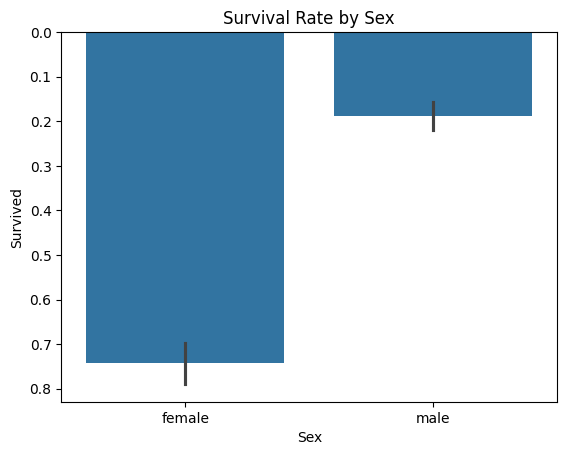

/tmp/ipython-input-1332838748.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("Sex")["Survived"].mean())


TypeError: category dtype does not support aggregation 'mean'

In [3]:
sns.barplot(x="Sex", y="Survived", data=df)
plt.title("Survival Rate by Sex")
plt.show()

print(df.groupby("Sex")["Survived"].mean())

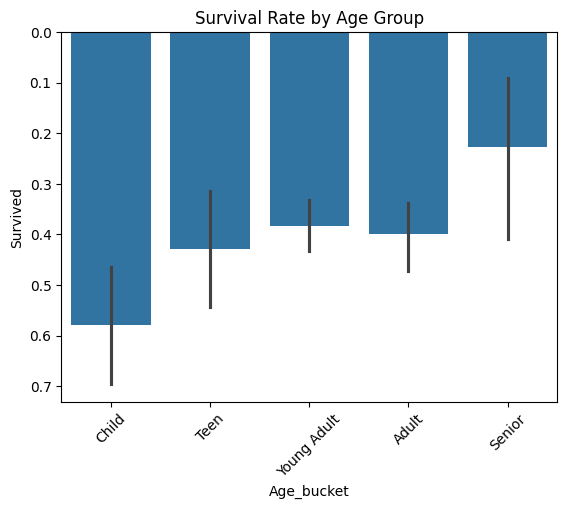

/tmp/ipython-input-2326086717.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("Age_bucket")["Survived"].mean())


TypeError: category dtype does not support aggregation 'mean'

In [4]:
df["Age_bucket"] = pd.cut(df["Age"],
                          bins=[0,12,18,35,60,100],
                          labels=["Child","Teen","Young Adult","Adult","Senior"])

sns.barplot(x="Age_bucket", y="Survived", data=df)
plt.xticks(rotation=45)
plt.title("Survival Rate by Age Group")
plt.show()

print(df.groupby("Age_bucket")["Survived"].mean())

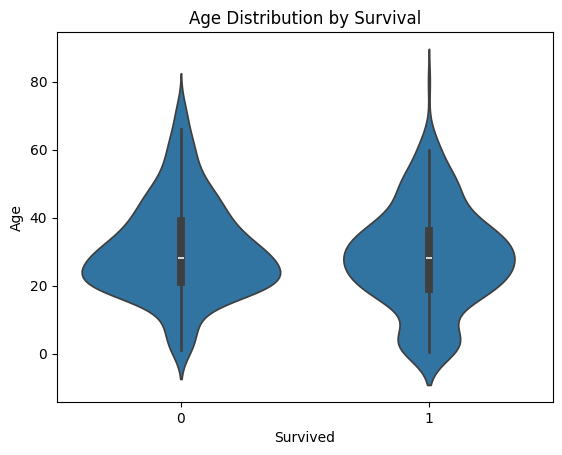

In [5]:
sns.violinplot(x="Survived", y="Age", data=df)
plt.title("Age Distribution by Survival")
plt.show()

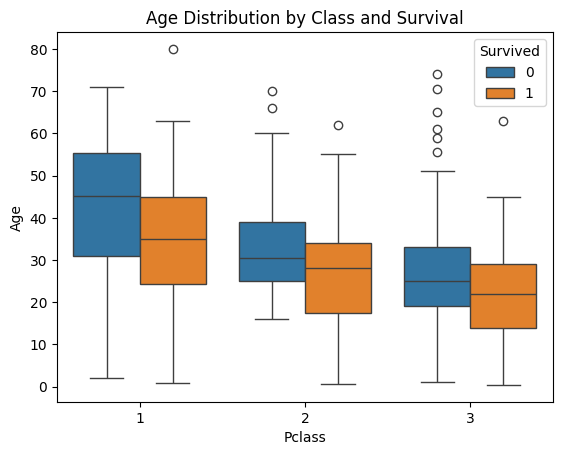

In [6]:
sns.boxplot(x="Pclass", y="Age", hue="Survived", data=df)
plt.title("Age Distribution by Class and Survival")
plt.show()

Women had significantly higher survival rates than men, indicating priority evacuation (“women and children first” policy).

1st class passengers had much higher survival rates than 2nd and especially 3rd class passengers.

Children showed relatively higher survival rates, particularly in upper classes.

3rd class adult males had the lowest survival probability, suggesting socioeconomic status strongly influenced outcomes.

Age alone was less predictive than Sex + Pclass combined.